In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import warnings
import kagglehub
from genericpath import isfile
warnings.filterwarnings('ignore')

df3 = pd.read_csv('Dataset3.csv', engine='python')
print(df3.shape)

columns_to_drop = ['id', 'date', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15']
df3 = df3.drop(columns=[col for col in columns_to_drop if col in df3.columns])
print(df3.columns.tolist())
print(df3.shape)

df3.dropna(inplace=True)
target_column = 'price'
numerical_features = [col for col in df3.columns if col != target_column]
scaler = StandardScaler()
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])
categorical_cols_to_encode = df3.select_dtypes(include='object').columns
df3 = pd.get_dummies(df3, columns=categorical_cols_to_encode, drop_first=True)
features = [col for col in df3.columns if col != target_column]
X = df3[features].copy()
y = df3[target_column].copy()
print("=" * 60)
print("DATASET 3")
print("=" * 60)

print("\nFirst 10 rows:")
display(df3.head(10))

print("\nData types:")
print(df3.dtypes)

print("\nMissing values:")
print(df3.isnull().sum())

print("\nTarget variable (price) statistics:")
print(df3['price'].describe())



(21613, 21)
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'lat', 'long']
(21613, 15)
DATASET 3

First 10 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long
0,221900.0,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.352572,-0.306079
1,538000.0,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,1.161568,-0.746341
2,180000.0,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,1.283537,-0.135655
3,604000.0,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.283288,-1.271816
4,510000.0,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,0.409550,1.199335
5,1225000.0,0.676485,3.097133,3.636791,2.096185,-0.915427,-0.087173,-0.305759,-0.629187,2.844170,2.537955,2.798440,1.021181,0.693181,1.483375
6,257500.0,-0.398737,0.175607,-0.397313,-0.200098,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.088628,-0.658681,0.816910,-1.806810,-0.803149
7,291850.0,-0.398737,-0.798235,-1.110494,-0.130276,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.879623,-0.658681,-0.272536,-1.086547,-0.717937
8,229500.0,-0.398737,-1.447464,-0.326539,-0.184381,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.891699,0.990795,-0.374672,-0.344633,-0.874160
9,323000.0,-0.398737,0.500221,-0.206768,-0.206351,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.122706,-0.658681,1.089271,-1.383168,1.298749



Data types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
lat              float64
long             float64
dtype: object

Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
lat              0
long             0
dtype: int64

Target variable (price) statistics:
count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


the dateset contains  21613  records with  14 features
Before cross validation
 MSE 46299047745.62454
 RMAE 215172.13515142835
 r2 0.6937421970987158
After cross validation
 MSE: 40271571858.77844
 RMAE 200239.5005749914
 r2 0.6924192097274419


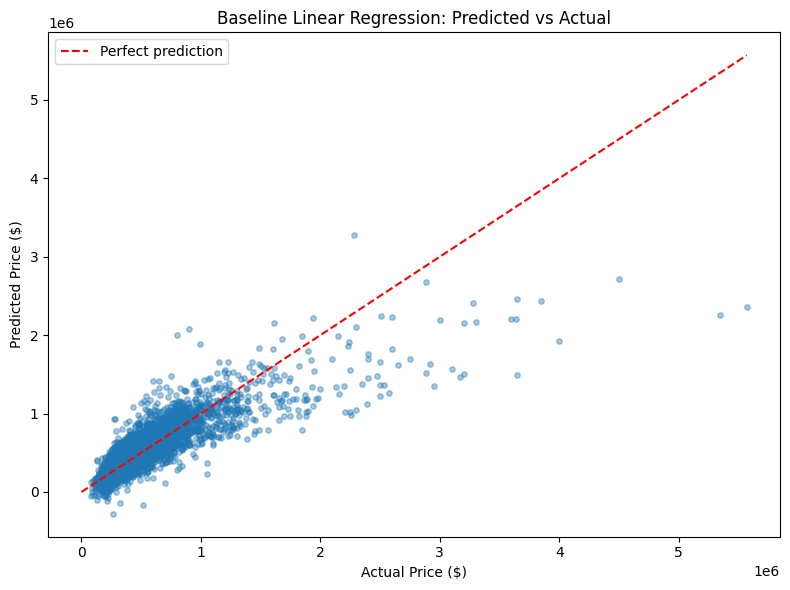

In [12]:
from sklearn.model_selection import cross_val_score, KFold,cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error,get_scorer_names
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

nrow,ncol = X.shape
print("the dateset contains ",nrow," records with ",ncol,"features")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

model = LinearRegression()
model.fit(X_train,y_train)
predictions = model.predict(X_test)

print("Before cross validation")
print(" MSE", metrics.mean_squared_error(y_test, predictions))
print(" RMAE", metrics.root_mean_squared_error(y_test, predictions))
print(" r2", metrics.r2_score(y_test, predictions))

cv_results = cross_validate(model,X_train,y_train,cv=5,scoring=('neg_mean_squared_error','neg_root_mean_squared_error','r2'),return_train_score=True)
print("After cross validation")
print(" MSE:", -cv_results['test_neg_mean_squared_error'].mean())
print(" RMAE",-cv_results['test_neg_root_mean_squared_error'].mean())
print(" r2",cv_results['test_r2'].mean())


plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.4, s=15)
max_val = max(y_test.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Baseline Linear Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

before cross validaion ,from our results, the mean square error was very large approximately 46 billion, which when working with prices of hunderds of thoursand which are then squared can happen making this less interpretable as it represents dollars.

However the root mean square error, sq_root(mse), explains that our model was off by $215 172 on averge when prdicting houses but when squaring the values they are susceptible to outliars, which the dataset has, visible in the scatter plot.

the r_sq value of 0.69 showed that our model predicts 69% of the variance of the dataset

 after cross_validation, we can see a decrese in results as the mean square error was reduced t0 approximately 40 billion, the root mean square error, was reduced to approximately 200 000, meaning there was a decrease in how much our prediction were off by but the r2 value was till approximately 0.69, meaning our model still represents 69% of the variance of the dataset.

from these results we can conclude the model predicted fairly .

limitation : the inclusion of outliars